### Plate Reverb Implementation
This Notebook implements a mono-in, stereo-out plate reverb as described by Jon Dattorro in Effect Design Part 1: Reverberator and Other Filters.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import math

In [38]:
class DelayLine:

    # Initialize a fixed-length circular buffer and write pointer.
    def __init__(self, length, fill_value=0.0):
        length = int(length)
        if length <= 0:
            raise ValueError("length must be a positive integer")

        self.length = length
        # Fixed-size circular buffer for delayed samples.
        self._buffer = [fill_value] * self.length
        # -1 means no writes yet and first write lands at index 0.
        self._write_idx = -1

    # Write one new sample into the line at the current time step.
    def write(self, sample):
        # Advance write pointer with wraparound, then store sample.
        self._write_idx = (self._write_idx + 1) % self.length
        self._buffer[self._write_idx] = sample

    # Return the sample n positions behind the write pointer.
    def tap(self, n):
        n = int(n)
        if n < 0 or n >= self.length:
            raise IndexError(f"tap index must be in [0, {self.length - 1}]")

        # Read n samples behind write pointer.
        read_idx = (self._write_idx - n) % self.length

        return self._buffer[read_idx]

    # Clear the delay line and reset write position.
    def reset(self, fill_value=0.0):
        self._buffer = [fill_value] * self.length
        self._write_idx = -1

In [39]:
class OnePoleLowpassFilter:

    # Create a one-pole lowpass with damping or bandwidth control mapping.
    def __init__(self, control=0.5, mode="damping", initial_state=0.0):
        self.mode = str(mode).lower()
        self.control = None
        self.a = 0.0  # One-pole feedback coefficient (smoothing amount).
        self.z1 = float(initial_state)
        self.set_control(control, mode)

    # Update the control value and mapping mode.
    def set_control(self, control, mode=None):
        if mode is not None:
            self.mode = str(mode).lower()
        control = float(control)  # User control amount.
        self.control = control
        
        # Pole coefficient in y[n] = (1-a)x[n] + a*y[n-1].
        self.a = control if self.mode == "damping" else 1.0 - control  # Damping: more control => more smoothing; bandwidth: inverse.

    # Process one sample through the filter.
    def process(self, x):
        x = float(x)
        y = (1.0 - self.a) * x + self.a * self.z1
        self.z1 = y
        return y

    # Process an iterable of samples.
    def process_block(self, samples):
        return [self.process(x) for x in samples]

    # Reset the internal filter memory.
    def reset(self, value=0.0):
        self.z1 = float(value)

In [40]:
class ModulatedAllpass:

    # Initialize an allpass delay with sine LFO modulation.
    def __init__(self, max_delay_samples, delay_samples, gain=0.5, sample_rate=48000.0, lfo_rate_hz=5.0, lfo_depth_samples=0.0, lfo_phase=0.0, fill_value=0.0):
        self.max_delay = float(max_delay_samples)
        self.delay = float(delay_samples)
        self.gain = float(gain)
        self.sample_rate = float(sample_rate)
        self.lfo_rate = float(lfo_rate_hz)
        self.lfo_depth = float(lfo_depth_samples)
        self.lfo_phase = float(lfo_phase)

        self.buffer = [float(fill_value)] * (int(self.max_delay) + 3)
        self.write_idx = -1
        self.ap_x1 = 0.0
        self.ap_y1 = 0.0
        self.set_delay(delay_samples)

    # Set base delay in samples.
    def set_delay(self, delay_samples):
        d = float(delay_samples)
        if d < 0.0:
            d = 0.0
        if d > self.max_delay:
            d = self.max_delay
        self.delay = d

    # Return sample at point n (or current base delay if n is None).
    def tap(self, n=None):
        d = self.delay if n is None else float(n)
        if d < 0.0:
            d = 0.0
        if d > self.max_delay:
            d = self.max_delay

        n_int = int(d)
        frac = d - n_int
        x0 = self.buffer[(self.write_idx - n_int) % len(self.buffer)]
        if frac < 1e-12:
            return x0

        eta = (1.0 - frac) / (1.0 + frac)
        y = eta * x0 + self.ap_x1 - eta * self.ap_y1
        self.ap_x1, self.ap_y1 = x0, y
        return y

    # Process one sample through the allpass with LFO-modulated delay.
    def process(self, x):
        mod_delay = self.delay + self.lfo_depth * math.sin(self.lfo_phase)
        d = self.tap(mod_delay)
        w = float(x) + self.gain * d
        y = d - self.gain * w

        self.write_idx = (self.write_idx + 1) % len(self.buffer)
        self.buffer[self.write_idx] = w

        if self.sample_rate > 0.0:
            self.lfo_phase += (2.0 * math.pi * self.lfo_rate) / self.sample_rate
            self.lfo_phase %= (2.0 * math.pi)
        return y

    # Process a block of samples.
    def process_block(self, samples):
        return [self.process(x) for x in samples]

    # Reset delay memory and interpolation state.
    def reset(self, fill_value=0.0):
        self.buffer = [float(fill_value)] * len(self.buffer)
        self.write_idx = -1
        self.ap_x1 = 0.0
        self.ap_y1 = 0.0
        self.lfo_phase = 0.0

In [41]:
# Core blocks
Predelay = DelayLine(int(0.020 * 48000))  # 20 ms at 48 kHz
Bandwidth = OnePoleLowpassFilter(0.5, "bandwidth", 0.0)
DampingL = OnePoleLowpassFilter(0.5, "damping", 0.0)
DampingR = OnePoleLowpassFilter(0.5, "damping", 0.0)
Decay = 0.5

# Input diffusers
APF1 = ModulatedAllpass(max_delay_samples=210, delay_samples=210, gain=0.75)
APF2 = ModulatedAllpass(max_delay_samples=158, delay_samples=158, gain=0.75)
APF3 = ModulatedAllpass(max_delay_samples=561, delay_samples=561, gain=0.625)
APF4 = ModulatedAllpass(max_delay_samples=410, delay_samples=410, gain=0.625)

# Tank (left/right)
MAPF1 = ModulatedAllpass(max_delay_samples=1343 + 12, delay_samples=1343, gain=0.7, lfo_rate_hz=0.10, lfo_depth_samples=12)
Delay1 = DelayLine(6241)
APF5 = ModulatedAllpass(max_delay_samples=3931, delay_samples=3931, gain=0.5)
Delay2 = DelayLine(4681)

MAPF2 = ModulatedAllpass(max_delay_samples=995 + 12, delay_samples=995, gain=0.7, lfo_rate_hz=0.07, lfo_depth_samples=12)
Delay3 = DelayLine(6590)
APF6 = ModulatedAllpass(max_delay_samples=2664, delay_samples=2664, gain=0.5)
Delay4 = DelayLine(5505)

_tank_fb_l = 0.0
_tank_fb_r = 0.0

def _process_delay(delay_obj, x):
    y = delay_obj.tap(delay_obj.length - 1)
    delay_obj.write(x)
    return y

def process_reverb_sample(x):
    global _tank_fb_l, _tank_fb_r

    Predelay.write(x)
    u = Predelay.tap(Predelay.length - 1)
    u = Bandwidth.process(u)

    u = APF1.process(u)
    u = APF2.process(u)
    u = APF3.process(u)
    u = APF4.process(u)

    in_l = u + Decay * _tank_fb_r
    in_r = u + Decay * _tank_fb_l

    s_l = MAPF1.process(in_l)
    s_l = _process_delay(Delay1, s_l)
    s_l = DampingL.process(s_l)
    s_l = APF5.process(s_l)
    _tank_fb_l = _process_delay(Delay2, s_l)

    s_r = MAPF2.process(in_r)
    s_r = _process_delay(Delay3, s_r)
    s_r = DampingR.process(s_r)
    s_r = APF6.process(s_r)
    _tank_fb_r = _process_delay(Delay4, s_r)

    y_L = (Delay1.tap(394) + Delay1.tap(4401) - APF5.tap(2831) + Delay2.tap(2954)
           - Delay3.tap(2945) - APF6.tap(277) - Delay4.tap(1066))

    y_R = (Delay3.tap(522) + Delay3.tap(5368) - APF6.tap(1817) + Delay4.tap(3956)
           - Delay1.tap(3124) - APF5.tap(496) - Delay2.tap(179))

    return y_L, y_R

In [42]:
# Spectrogram function for visualization.
def spectrogram(x, Fs, title='Log-Frequency Spectrogram', NFFT=4096, noverlap=3584):
    f, t, Sxx = signal.spectrogram(x, fs=Fs, window='hann', nperseg=NFFT, noverlap=noverlap, nfft=8192, scaling='spectrum')
    Sxx_db = 10 * np.log10(Sxx + 1e-20)
    Sxx_db -= np.max(Sxx_db)
    Sxx_db = np.clip(Sxx_db, -60, 0)

    f_log = np.logspace(np.log10(max(f[1], 1)), np.log10(f[-1]), len(f))
    Sxx_log = np.zeros((len(f_log), Sxx_db.shape[1]))
    for i in range(Sxx_db.shape[1]):
        Sxx_log[:, i] = np.interp(f_log, f, Sxx_db[:, i])

    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f_log, Sxx_log, shading='gouraud', cmap='viridis')
    plt.yscale('log')
    plt.ylim(f_log[0], f_log[-1])
    ticks = np.unique(np.logspace(np.log10(f_log[0]), np.log10(f_log[-1]), 10, dtype=int))
    plt.yticks(ticks, labels=[str(tk) for tk in ticks])
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz) - Log Scale')
    plt.colorbar(label='Intensity (dB)')
    plt.grid(True, which='both', axis='y', ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_19787/1342856298.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, x = wavfile.read('snare.wav')


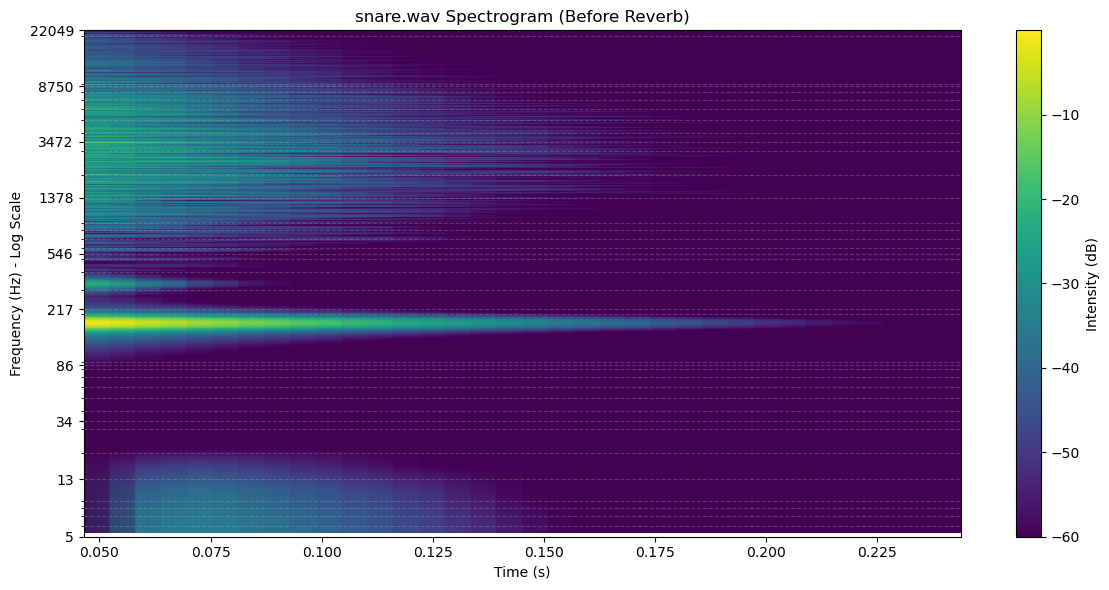

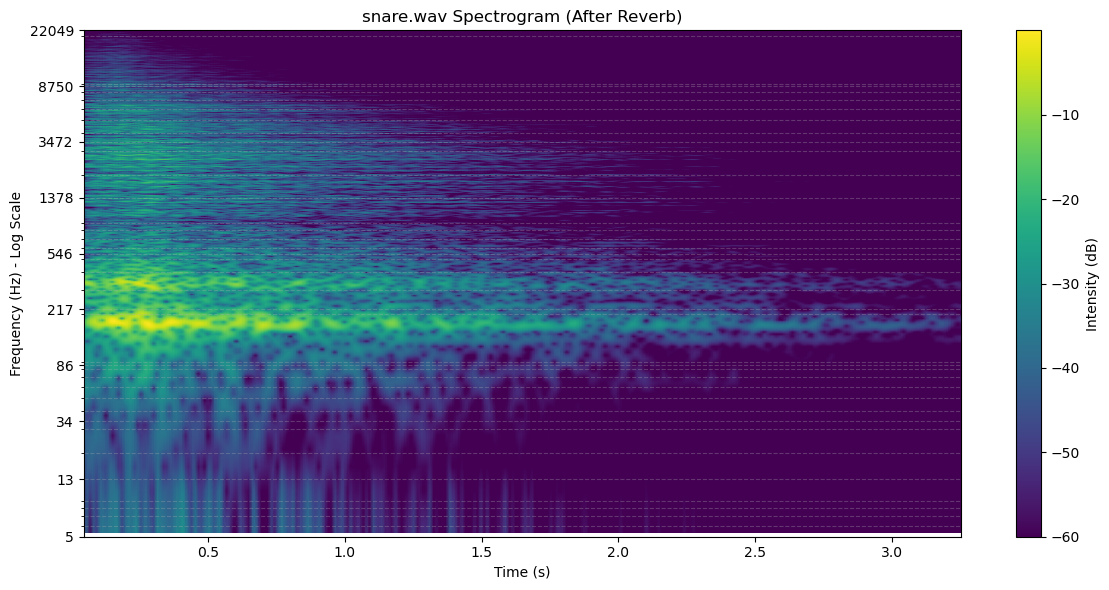

In [ ]:
# Load input
Fs, x = wavfile.read('snare.wav')

# Match modulation to file sample-rate
MAPF1.sample_rate = float(Fs)
MAPF2.sample_rate = float(Fs)

# Apply reverb
x_in = np.concatenate([x, np.zeros(int(3.0 * Fs), dtype=np.float32)])
y = np.zeros((len(x_in), 2), dtype=np.float32)
for i, s in enumerate(x_in):
    y[i] = process_reverb_sample(float(s))
y *= 0.95 / max(np.max(np.abs(y)), 1e-12)

# Display audio + spectrograms
display(Audio(x, rate=Fs))
spectrogram(x, Fs, 'snare.wav Spectrogram (Before Reverb)')
display(Audio(y.T, rate=Fs))
spectrogram(y.mean(axis=1), Fs, 'snare.wav Spectrogram (After Reverb)')
